# Service Operations Planning Model: demand forecast and workforce capacity

**Important:** all data in this project is **simulated**. Volumes, handling times, staffing levels and the provider contract cap are illustrative assumptions, not real organisational data.

**The question:** a financial services customer operations team handles phone calls and back-office cases. Over the next 13 weeks, how much work should we expect, how many people does that need, and where will we be short?

**Approach, in four steps**
1. Forecast weekly demand and test how accurate the forecast is on weeks the model has not seen.
2. Convert forecast demand into workload hours and required FTE (full-time equivalent staff).
3. Compare required FTE with available FTE under three scenarios and size any shortfall.
4. Check the outsourced provider's forecast volume against its contracted weekly volume.

In [1]:
import pandas as pd
from IPython.display import Image, display
from forecast_and_capacity import ASSUMPTIONS as A, productive_hours

data = pd.read_csv("data/service_ops_demand.csv", parse_dates=["week_start"])
print(f"{len(data)} weeks, {data.week_start.min().date()} to {data.week_start.max().date()}")
data.tail()

156 weeks, 2023-10-09 to 2026-09-28


,week_start,calls,cases_bau,cases_change,cases_outsourced,fte_available
151,2026-08-31,4395,3026,0,738,64.8
152,2026-09-07,4286,2921,0,718,63.4
153,2026-09-14,4497,3096,0,782,62.6
154,2026-09-21,4853,3193,0,828,65.0
155,2026-09-28,5075,2963,0,726,65.5


## 1. The data

Each row is one week. `calls` are inbound phone contacts. `cases_bau` are back-office cases (for example transfers, account changes, document processing). `cases_change` are extra cases from a past change project (a system migration campaign). `cases_outsourced` is the share handled by an outsourced provider. `fte_available` is in-house staff.

The simulated pattern has an upward trend of about 3% a year, a busier period around the tax-year end in March and April, a quiet summer, a small uplift in the week containing month end, and a dip in the bank-holiday week at year end.

In [2]:
data["month"] = data.week_start.dt.month
seasonality = data.groupby("month")[["calls", "cases_bau"]].mean().round(0)
seasonality

,calls,cases_bau
month,,
1,4698.0,2882.0
2,4429.0,2745.0
3,4914.0,3378.0
4,4921.0,3396.0
5,4534.0,2724.0
6,4377.0,2599.0
7,4076.0,2527.0
8,4075.0,2508.0
9,4558.0,2802.0


## 2. Forecasting method and why

The forecast covers **business-as-usual (BAU) demand only**. The change project's extra cases are kept separate because they are a known, planned input rather than a pattern to learn from history.

Two models are compared:
- **Seasonal naive:** this week's forecast is the same week last year. It is the simple benchmark. A forecasting model has to beat it to be worth using.
- **Holt-Winters:** a smoothing model that learns the level, the trend and the yearly seasonal pattern.

**How accuracy is tested:** the last 13 weeks of history are hidden, both models forecast them, and the forecasts are compared with what actually happened. **MAPE** is the average percentage miss. **Bias** shows whether the forecast is consistently too high or too low.

In [3]:
accuracy = pd.read_csv("outputs/accuracy_backtest.csv")
accuracy

,series,model,MAPE_pct,bias_pct,RMSE
0,calls,Seasonal naive,4.72,-3.71,246.9
1,calls,Holt-Winters,3.78,-0.46,189.5
2,cases_bau,Seasonal naive,5.46,-3.65,195.7
3,cases_bau,Holt-Winters,5.20,-2.50,178.6


**Reading this:** Holt-Winters beats the seasonal naive benchmark on both series, by a clear margin for calls and a small one for cases. Both are slightly under-forecasting (negative bias) because growth is not fully captured. A weekly planner would track this each week and re-forecast when the gap widens.

**Caveat:** the data was generated with simple, regular seasonality, so it is easier to forecast than real demand. These accuracy figures show the method works, not what accuracy to expect on real data.

In [4]:
bt = pd.read_csv("outputs/backtest_weekly.csv")
print("Weeks beyond +/-10% of actual:", int(bt.flag.sum()), "of", len(bt))
bt[bt.series == "calls"].head(6)

Weeks beyond +/-10% of actual: 0 of 26


,week_start,series,model,actual,forecast,variance_pct,flag
0,2026-07-06,calls,Holt-Winters,4241,4205,0.8,False
1,2026-07-13,calls,Holt-Winters,4064,4187,-3.0,False
2,2026-07-20,calls,Holt-Winters,4131,4325,-4.7,False
3,2026-07-27,calls,Holt-Winters,4347,4049,6.9,False
4,2026-08-03,calls,Holt-Winters,4090,3977,2.8,False
5,2026-08-10,calls,Holt-Winters,4295,3979,7.4,False


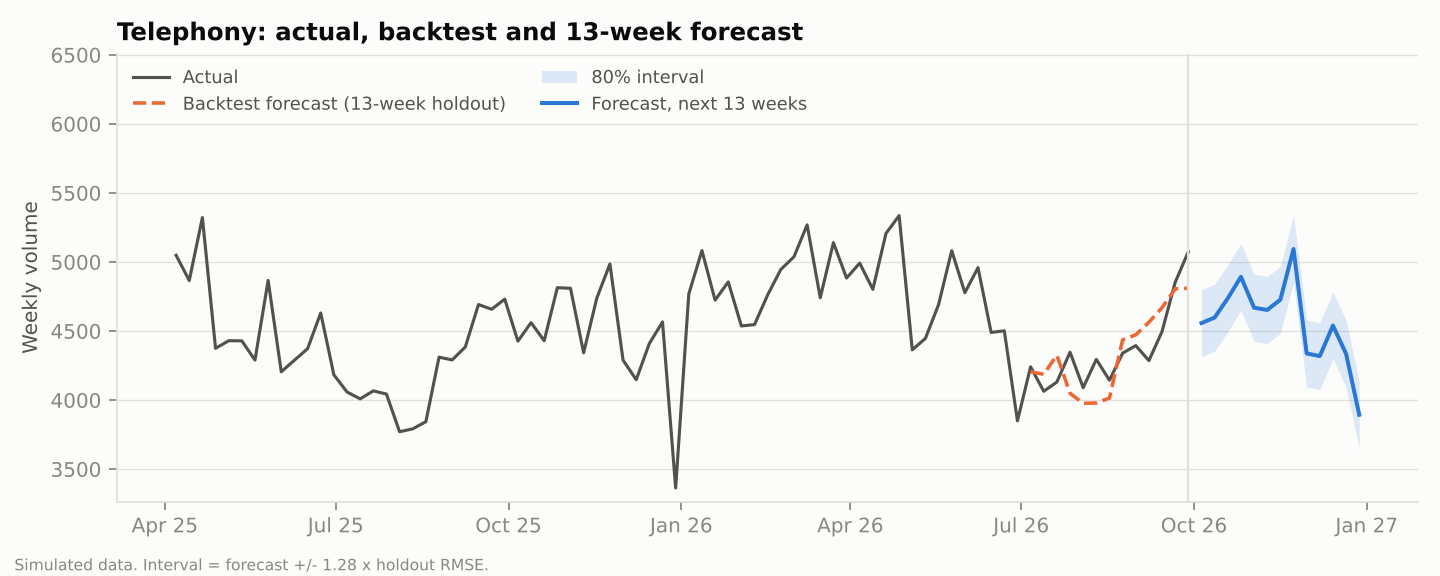

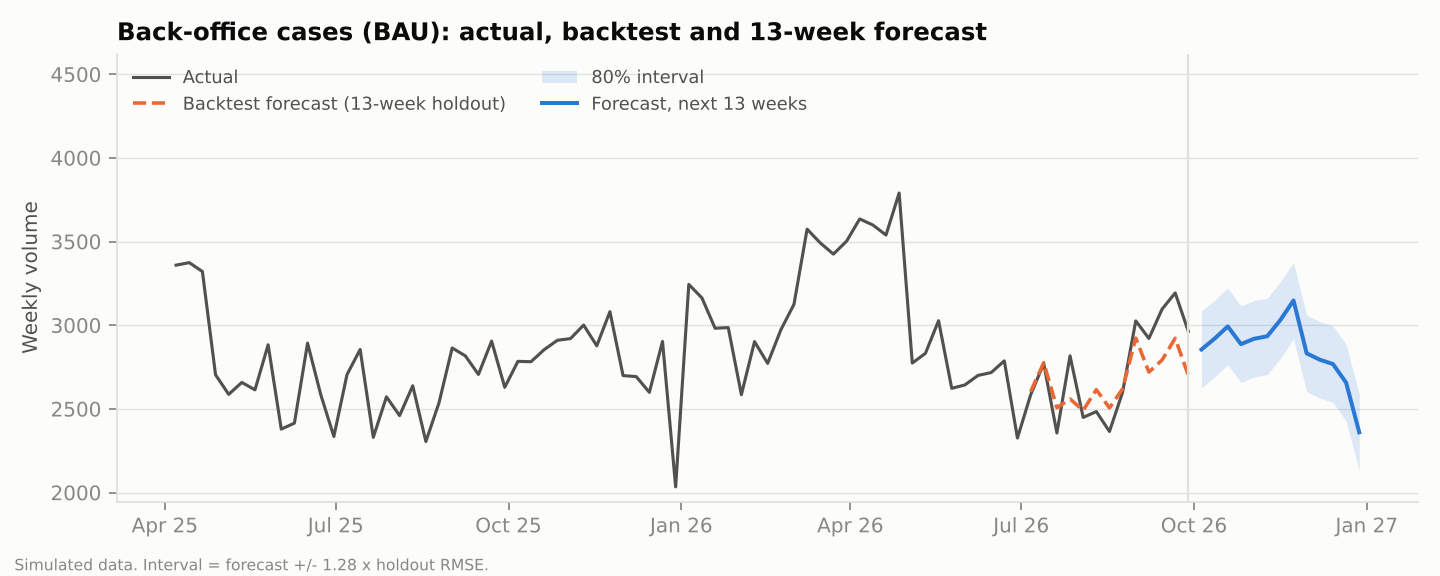

In [5]:
display(Image("outputs/charts/forecast_calls.png"))
display(Image("outputs/charts/forecast_cases.png"))

The shaded band is an 80% interval built from how far the model missed on the holdout weeks. It expresses confidence: actual demand should land inside the band about four weeks in five.

## 3. From demand to people (capacity)

**Workload hours** = calls x handling time per call + in-house cases x handling time per case. Cases routed to the outsourced provider are excluded because in-house staff do not handle them.

**Productive hours per FTE** = contracted hours x (1 - shrinkage) x occupancy. Shrinkage is time lost to holidays, sickness, training and meetings. Occupancy is the share of the remaining time actually spent on work.

**Required FTE** = workload hours / productive hours per FTE.

In [6]:
print("Productive hours per FTE per week:", round(productive_hours(), 2))
fc = pd.read_csv("outputs/forecast_13wk.csv")
w = fc.iloc[7]
calls_h = w.calls_forecast * A["aht_call_min"] / 60
cases_h = w.cases_bau_forecast * (1 - A["outsourced_share"]) * A["aht_case_min"] / 60
print(f"Worked example, week of {w.week_start}:")
print(f"  calls {w.calls_forecast:,} x {A['aht_call_min']} min = {calls_h:,.1f} hours")
print(f"  in-house cases {w.cases_bau_forecast * (1 - A['outsourced_share']):,.0f} x {A['aht_case_min']} min = {cases_h:,.1f} hours")
print(f"  workload {calls_h + cases_h:,.1f} hours / {productive_hours():.2f} productive hours per FTE = {(calls_h + cases_h) / productive_hours():.1f} FTE required")

Productive hours per FTE per week: 22.31
Worked example, week of 2026-11-23:
  calls 5,094 x 7 min = 594.3 hours
  in-house cases 2,361 x 22 min = 865.7 hours
  workload 1,460.0 hours / 22.31 productive hours per FTE = 65.4 FTE required


## 4. Scenarios

Planners rarely get one version of the future, so three are modelled:
1. **Base:** BAU demand only.
2. **Base + change project:** adds a planned campaign of extra cases over six weeks.
3. **Change + peak + absence:** scenario 2 plus 10% more volume and 35% shrinkage in five peak weeks. This is a deliberate stress test, not a prediction.

Planned staffing movements (two leavers, three trained hires) are included in available FTE. A shortfall is covered first by overtime (up to 4 hours per FTE per week). Whatever remains is shown as temporary or recruited FTE needed.

In [7]:
pd.read_csv("outputs/scenario_summary.csv")

,scenario,peak_required_fte,weeks_short,peak_gap_fte,max_temp_fte_after_overtime,weeks_provider_over_cap
0,1 Base (BAU only),65.4,1,3.3,0,0
1,2 Base + change project,68.5,4,6.3,0,3
2,3 Change + peak + absence,81.1,6,19.0,7,4


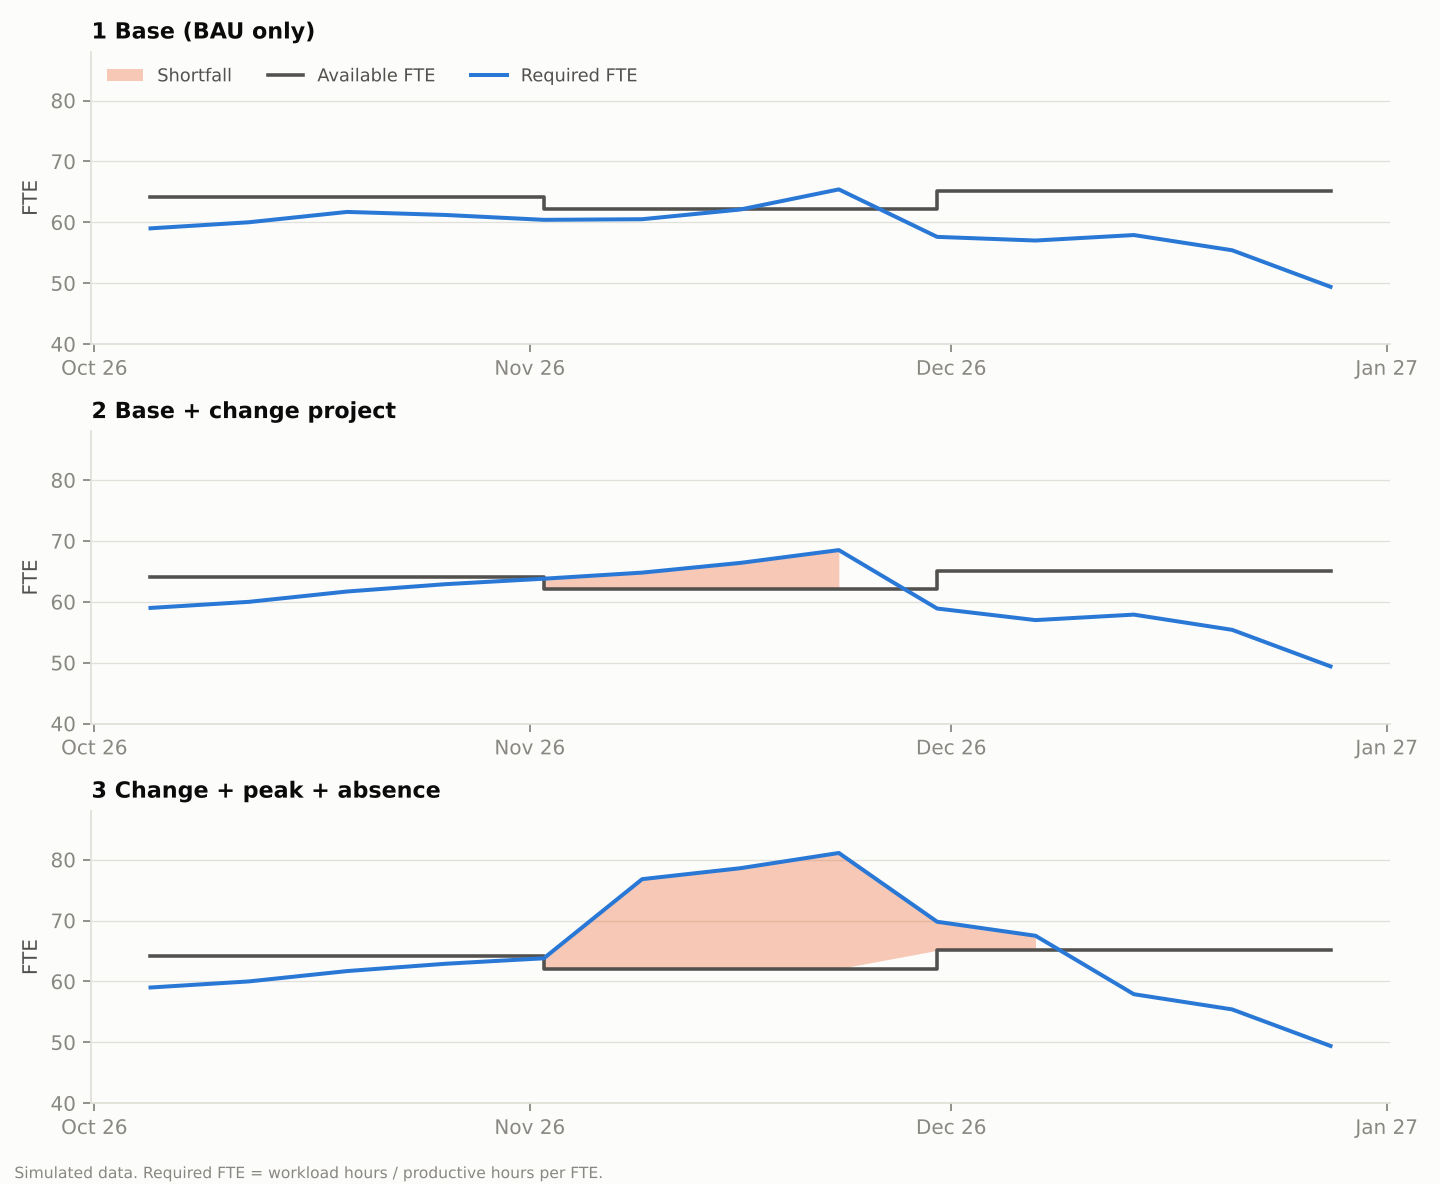

In [8]:
display(Image("outputs/charts/capacity_scenarios.png"))

## 5. Outsourced provider tracking

The provider handles a share of cases under a contracted weekly volume. Comparing forecast volume with that limit gives early warning of weeks where the provider may exceed its contract, so the conversation can start before it happens.

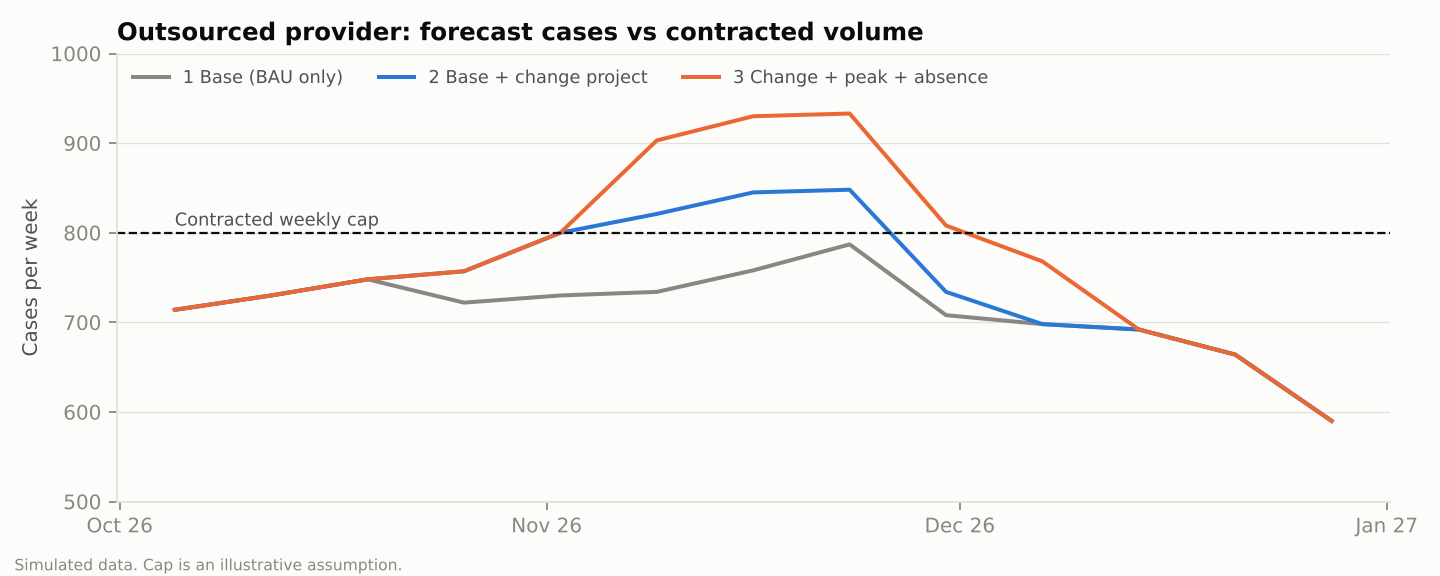

In [9]:
display(Image("outputs/charts/provider_vs_cap.png"))

## 6. Limitations and next steps

- All data and assumptions are simulated and illustrative. Real work would use actual contact volumes, handling times and rosters.
- Handling times, shrinkage and occupancy are single averages. In practice they vary by team and season.
- Weekly granularity hides intraday and day-of-week patterns. A telephony plan would use an Erlang C staffing calculation on interval data.
- With real data, forecast accuracy should be tracked weekly, with a reforecast whenever variance moves beyond a set threshold.
- The workbook `Service_Ops_Planning_Model.xlsx` repeats the capacity logic with live formulas, so assumptions can be changed and scenarios compared without code.